In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    TrainingArguments,
    Trainer,
    pipeline
)

from transformers.pipelines.pt_utils import KeyDataset
import evaluate

# FINE-TUNING FOR CLASSIFICATION


In [2]:
df = pd.read_csv('filtered_arabic_sentiment_reviews.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,label,content,cleaned_content,txt_len
0,0,278767,1,أفضل موقد قرص مضغوط على الإطلاق !!!!: على الرغ...,افضل موقد قرص مضغوط علي الاطلاق علي الرغم ان ا...,83
1,1,33767,0,ما هو الخطأ في الكاثوليكية: الولاء للفاتيكان ش...,الخطا الكاثوليكيه الولاء لفاتيكان شيء معروف ام...,49
2,2,44383,0,واحد أقل من العميل مدى الحياة: أدى رأس سيئ الت...,اقل العميل مدي الحياه ادي راس سيئ التصميم السل...,47
3,3,105940,0,مضيعة للوقت والمال: لقد تملصت مع هذا لمدة 20 د...,مضيعه لوقت والمال لقد تملصت لمده دقيقه تقريب ا...,38
4,4,292021,0,احترس !!!: احترس من هذا المنتج.صنع ما مجموعه ت...,احترس احترس المنتج صنع مجموعه تسعه اواني عندما...,48


In [3]:
id2label = {0 : "Negative", 1 : "Positive"}
label2id = {"Negative" : 0, "Positive" : 1}

In [4]:
tokenizer = AutoTokenizer.from_pretrained('mlm')
def preprocess_function(examples) : 
    return tokenizer(examples['text'] , truncation = True)

In [5]:
ds = Dataset.from_dict({
    "text": df['cleaned_content'].values,
    "label": df['label'].values
})

In [6]:
print(f"Review : {ds['text'][2]}\nRating : {ds['label'][2]}")

Review : اقل العميل مدي الحياه ادي راس سيئ التصميم السلسله الي انهيار الخلاط حرفي الطعام كنت اقوم اقسمت بالمساعدات المطبخ عندما عملت المطاعم اقنعت زوجتي بالتواصل معي شراء المحترف الان ولائي يجعلني ابدو احمق اطلقنا علي ، لكنهم فشلوا الوقوف الي جانب الخلاط وفقدوا مدافع قوي علامتهم التجاريه
Rating : 0


In [7]:
ds = ds.map(preprocess_function , batched = True)

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [8]:
train_testvalid = ds.train_test_split(test_size=0.2, seed=42)
test_valid = train_testvalid['test'].train_test_split(test_size=0.3, seed=42)

In [9]:
train_ds = train_testvalid['train']
val_ds = test_valid['train']
test_ds = test_valid['test']
print(f"train dataset : {len(train_ds)}")
print(f"validation dataset : {len(val_ds)}")
print(f"test dataset : {len(test_ds)}")

train dataset : 80000
validation dataset : 14000
test dataset : 6000


In [10]:
# initalize the model 
model = AutoModelForSequenceClassification.from_pretrained(
    'mlm',
    num_labels = 2,
    id2label = id2label,
    label2id = label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: mlm
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
# Pad to the longest sequence in the batch
data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

In [12]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred) : 
    logits , labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions = predictions, references = labels)
    f1 = f1_metric.compute(predictions = predictions, references = labels, average = "weighted")

    return {
        'Accuracy' : accuracy["accuracy"],
        'F1' : f1['f1']
    }

# Train the model


In [13]:
args = TrainingArguments(
    output_dir = 'cls_model',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    logging_strategy = "epoch",
    per_device_train_batch_size = 16, 
    per_device_eval_batch_size = 16,
    gradient_accumulation_steps = 2,
    num_train_epochs = 5, 
    learning_rate = 2e-5, 
    weight_decay = 0.01,
    bf16 = True,
    load_best_model_at_end = True, 
    metric_for_best_model="eval_F1",
    greater_is_better = True,
    report_to = "none"
)

In [14]:
trainer = Trainer(
    model = model,
    processing_class  = tokenizer,
    data_collator=data_collator,
    args = args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    compute_metrics = compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],

)

results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.668909,0.285006,0.880071,0.880070
2,0.464480,0.300182,0.888643,0.888605
3,0.355120,0.288374,0.894643,0.894585
4,0.263567,0.355694,0.896857,0.896850
5,0.200674,0.393620,0.895929,0.895928


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [15]:
for key , value in results.metrics.items() : 
    print(f"{key} : {value}")

train_runtime : 2402.6959
train_samples_per_second : 166.48
train_steps_per_second : 5.202
total_flos : 2.5404692925190464e+16
train_loss : 0.39055004150390626
epoch : 5.0


In [16]:
trainer_history_all = trainer.state.log_history[:-1]
trainer_history_all

[{'loss': 0.66890927734375,
  'grad_norm': 4.762584686279297,
  'learning_rate': 1.6001600000000003e-05,
  'epoch': 1.0,
  'step': 2500},
 {'eval_loss': 0.28500619530677795,
  'eval_Accuracy': 0.8800714285714286,
  'eval_F1': 0.8800701564672074,
  'eval_runtime': 21.8062,
  'eval_samples_per_second': 642.02,
  'eval_steps_per_second': 40.126,
  'epoch': 1.0,
  'step': 2500},
 {'loss': 0.46448037109375,
  'grad_norm': 4.504158973693848,
  'learning_rate': 1.20016e-05,
  'epoch': 2.0,
  'step': 5000},
 {'eval_loss': 0.300182044506073,
  'eval_Accuracy': 0.8886428571428572,
  'eval_F1': 0.8886047896087842,
  'eval_runtime': 20.7098,
  'eval_samples_per_second': 676.008,
  'eval_steps_per_second': 42.25,
  'epoch': 2.0,
  'step': 5000},
 {'loss': 0.3551197998046875,
  'grad_norm': 1.9096423387527466,
  'learning_rate': 8.0016e-06,
  'epoch': 3.0,
  'step': 7500},
 {'eval_loss': 0.28837358951568604,
  'eval_Accuracy': 0.8946428571428572,
  'eval_F1': 0.8945846179375577,
  'eval_runtime': 24

In [17]:
hist_data = {}
for item in trainer_history_all:
    epoch = item['epoch']
    if epoch not in hist_data:
        hist_data[epoch] = {'Epoch': epoch}
    if 'loss' in item:
        hist_data[epoch]['Training_Loss'] = item['loss']
    if 'eval_loss' in item:
        hist_data[epoch]['Eval_Loss'] = item['eval_loss']
    if 'eval_Accuracy' in item:
        hist_data[epoch]['eval_Accuracy'] = item['eval_Accuracy']
    if 'eval_F1' in item : 
        hist_data[epoch]['eval_F1'] = item['eval_F1']

model_metric = pd.DataFrame(hist_data.values())
print(model_metric)

   Epoch  Training_Loss  Eval_Loss  eval_Accuracy   eval_F1
0    1.0       0.668909   0.285006       0.880071  0.880070
1    2.0       0.464480   0.300182       0.888643  0.888605
2    3.0       0.355120   0.288374       0.894643  0.894585
3    4.0       0.263567   0.355694       0.896857  0.896850
4    5.0       0.200674   0.393620       0.895929  0.895928


Final Epoch Metrics:
Epoch            5.000000
Training_Loss    0.200674
Eval_Loss        0.393620
eval_Accuracy    0.895929
eval_F1          0.895928
Name: 4, dtype: float64


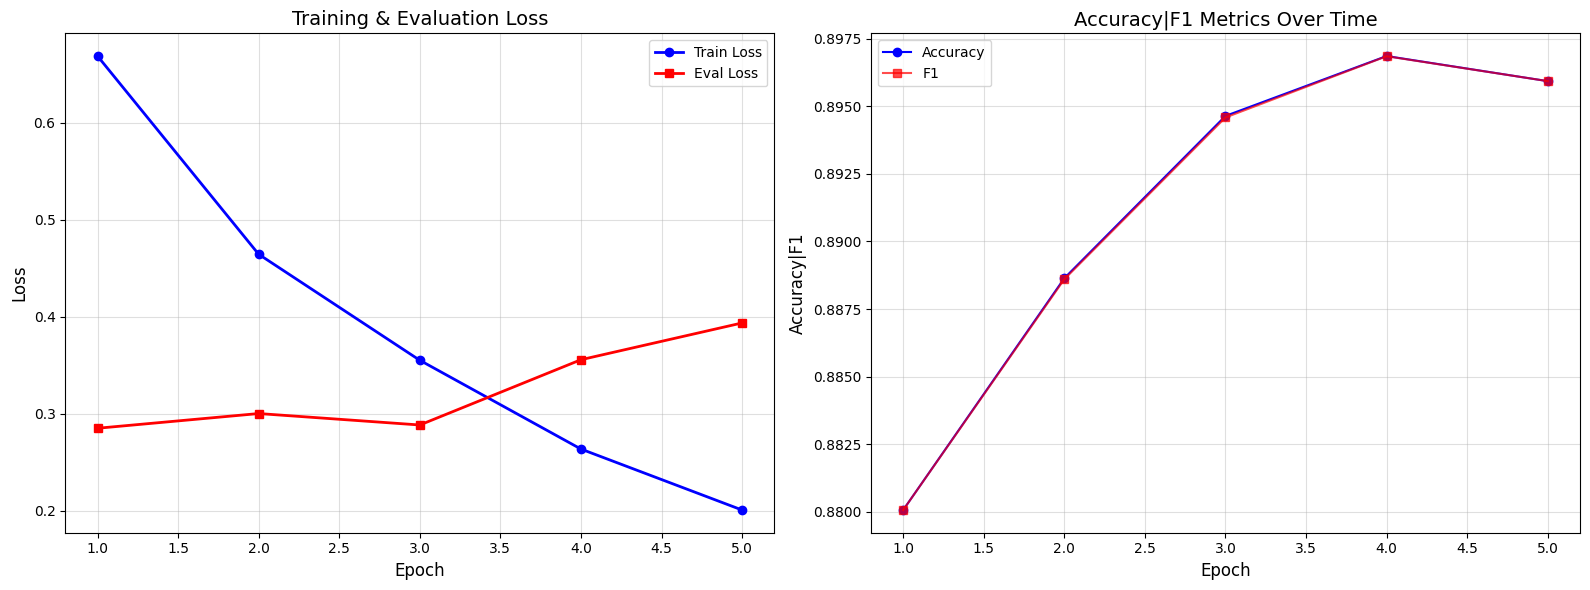

In [20]:
print("Final Epoch Metrics:")
print(model_metric.iloc[-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs = model_metric["Epoch"]
ax1.plot(epochs, model_metric["Training_Loss"], 'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs, model_metric["Eval_Loss"], 'r-s', label='Eval Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Evaluation Loss', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.4)

ax2.plot(epochs, model_metric["eval_Accuracy"], 'b-o', label='Accuracy')
ax2.plot(epochs, model_metric["eval_F1"], 'r-s', label='F1', alpha=0.7)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy|F1', fontsize=12)
ax2.set_title('Accuracy|F1 Metrics Over Time', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('training_and_eval_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate the model


In [21]:
eval_results = trainer.evaluate(test_ds)
eval_results

{'eval_loss': 0.3823176324367523,
 'eval_Accuracy': 0.8906666666666667,
 'eval_F1': 0.8906278315813706,
 'eval_runtime': 8.2972,
 'eval_samples_per_second': 723.139,
 'eval_steps_per_second': 45.196,
 'epoch': 5.0}

# Inference


In [22]:
# Save our fine-tuned model
trainer.save_model("cls_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
pipe = pipeline(
    "text-classification",
    model = model,
    tokenizer = tokenizer,
    dtype = 'float16', 
    device = 0
)

In [24]:
sentence = "ايه الحلاوة دي! بجد تحفة وتسلم ايديكم."
prediction = pipe(sentence)[0]
print(f"Predicted sentiment : {prediction['label']} => with Probability of {prediction['score']}\n")

Predicted sentiment : Positive => with Probability of 0.9653811454772949



In [25]:
sentence = "وحش اوي ، فلوسي راحت على الأرض."
prediction = pipe(sentence)[0]
print(f"Predicted sentiment : {prediction['label']} => with Probability of {prediction['score']}\n")

Predicted sentiment : Positive => with Probability of 0.8692712783813477



In [26]:
sentence = "المنتج وصل بعد شهر! شكراً على سلحفاتكم."
prediction = pipe(sentence)[0]
print(f"Predicted sentiment : {prediction['label']} => with Probability of {prediction['score']}\n")

Predicted sentiment : Positive => with Probability of 0.9890130758285522



In [27]:
sentence = "الجودة مقبولة نوعاً ما لكن السعر غالي."
prediction = pipe(sentence)[0]
print(f"Predicted sentiment : {prediction['label']} => with Probability of {prediction['score']}\n")

Predicted sentiment : Negative => with Probability of 0.6511330008506775



In [28]:
test_samples = test_ds.shuffle(seed = 12).take(6)
test_samples 

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6
})

In [29]:
predictions = list(
    pipe(
        KeyDataset(test_samples, "text"),
        batch_size=2,
        truncation=True
    )
)

In [30]:
for sample, pred in zip(test_samples, predictions) : 
    review_text = sample['text']
    gt_label = id2label[sample['label']]

    print(f"Review text : {review_text}\n")
    print(f"Ground Truth : {gt_label}\n")
    print(f"Predicted sentiment : {pred['label']} => with Probability of {pred['score']}\n")    
    print('='*80)

Review text : رفيق السفر المثالي اشتريت القضيه لزوجتي لاخذ الكاميرا معها رحلات انها مناسبه تمام لكاميرا وقمت بتصنيفها علي انها تبدو رائعه ايض

Ground Truth : Positive

Predicted sentiment : Positive => with Probability of 0.9985449314117432

Review text : الواح التهاب الاظافر ، الباهته ، والاظافر المزعجه اذن ، ، ، قصه العنوان المفترض ان تكون اي شيء اخر التمزق الصارخ لبريت ايستون اليس انت ، ، الواقع تفكر الامر ؟ فرحان

Ground Truth : Negative

Predicted sentiment : Negative => with Probability of 0.9190633296966553

Review text : سيئ يحصل اوتش ، فيلم الفقير بشكل يصدق التمثيل السيئ لغايه الكثير الضرب انقذ عينيك

Ground Truth : Negative

Predicted sentiment : Negative => with Probability of 0.9991169571876526

Review text : سخيف ضوء الواقع سته عام صنع ، المتع نوع ان نري يعتقد ان شخص هوليود سيكون بمثابه داعم معنوي رائع عرض قدراتنا العسكريه الان وبعد ان عرفنا حقيقه التعامل الارهابين الخارج ، تبدو المباني الواهيه لهذا الفيلم الصغير المتوحش اكثر سخافه جوهره فيلم غبي الوقت ، وفي فيلم اكثر حماق